In [2]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd


# Define the path to the event log directory
MLP_fed_avg_TR = [
    "../log/results/MLP_fed_avg_TR/_2025-03-07_00-07-42/events.out.tfevents.1741334862.ROG-Strix-GL12.1025839.0",
    "../log/results/MLP_fed_avg_TR/_2025-03-07_00-12-22/events.out.tfevents.1741335142.ROG-Strix-GL12.1025839.1",
    "../log/results/MLP_fed_avg_TR/_2025-03-07_00-16-54/events.out.tfevents.1741335414.ROG-Strix-GL12.1025839.2"
]

MLP_fed_avg_WTR = [
    "../log/results/MLP_fed_avg_WTR/_2025-03-07_06-28-28/events.out.tfevents.1741357708.ROG-Strix-GL12.1066450.0",
    "../log/results/MLP_fed_avg_WTR/_2025-03-07_06-53-21/events.out.tfevents.1741359201.ROG-Strix-GL12.1066450.1",
    "../log/results/MLP_fed_avg_WTR/_2025-03-07_07-17-27/events.out.tfevents.1741360647.ROG-Strix-GL12.1066450.2"
]

2025-03-07 14:10:32.678906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741385432.691528 1117193 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741385432.695463 1117193 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-07 14:10:32.708008: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
event = tf.compat.v1.train.summary_iterator(MLP_fed_avg_TR[0])
count = 0
for e in event:
    for v in e.summary.value:
        if v.tag == "Server_Test_F1_Score":
            print(e.step, v.tag, v.simple_value)
            count += 1
            if count == 3:
                break
    if count == 3:
        break

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
0 Server_Test_F1_Score 0.03824487328529358
1 Server_Test_F1_Score 0.5548502206802368
2 Server_Test_F1_Score 0.8095626831054688


In [15]:
df_dict = {}
algorithms = { "MLP_fed_avg_TR": MLP_fed_avg_TR, "MLP_fed_avg_WTR": MLP_fed_avg_WTR}

def extract_metrics(algorithm_name, log_files):
    data = {}
    for run_id, log_file in enumerate(log_files):
        if os.path.exists(log_file):
            for event in tf.compat.v1.train.summary_iterator(log_file):
                step = event.step
                key = (step, run_id, algorithm_name)
                if key not in data:
                    data[key] = {
                        "Step": step,
                        "Algorithm": algorithm_name,
                        "Run": run_id  # Track the run index
                    }

                # Extract each metric
                for value in event.summary.value:
                    if value.tag == "Server_Test_F1_Score":
                        data[key]["server_F1_Score"] = value.simple_value
                    elif value.tag == "Server_Test_Loss":
                        data[key]["server_loss"] = value.simple_value
                    elif value.tag == "Server_Test_Precision":
                        data[key]["server_precision"] = value.simple_value
                    elif value.tag == "Server_Test_Recall":
                        data[key]["server_recall"] = value.simple_value
                    elif value.tag == "Server_Test_Accuracy":
                        data[key]["server_accuracy"] = value.simple_value
                    elif value.tag == "Clients_agg/train_accuracy":
                        data[key]["train_accuracy"] = value.simple_value
                    elif value.tag == "Clients_agg/train_loss":
                        data[key]["train_loss"] = value.simple_value
                    elif value.tag == "Clients_agg/train_f1_score":
                        data[key]["train_f1_score"] = value.simple_value
        else:
            raise FileNotFoundError(f"File {log_file} not found")
    # Convert dictionary to a DataFrame
    df = df = pd.DataFrame.from_dict(data, orient="index")

    df = df.fillna(0)  # Fill NaN values with 0

    # Sort by Algorithm, Run, and Step
    df = df.sort_values(by=["Algorithm", "Run", "Step"]).reset_index(drop=True)

    return df if not df.empty else None

# Extract and store DataFrames
df_list = []
for algo_name, files in algorithms.items():
    df = extract_metrics(algo_name, files)
    if df is not None:
        df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all.head()

,Step,Algorithm,Run,server_accuracy,server_precision,server_recall,server_F1_Score,server_loss,train_accuracy,train_f1_score,train_loss
0,0,MLP_fed_avg_TR,0,0.069671,0.026497,0.069671,0.038245,0.037187,0.000000,0.000000,0.000000
1,1,MLP_fed_avg_TR,0,0.576877,0.782191,0.576877,0.554850,0.019307,0.963924,0.964193,0.907300
2,2,MLP_fed_avg_TR,0,0.792499,0.869963,0.792499,0.809563,0.013246,0.982317,0.982358,0.324756
3,3,MLP_fed_avg_TR,0,0.833984,0.888818,0.833984,0.846452,0.010781,0.988200,0.988238,0.171937
4,4,MLP_fed_avg_TR,0,0.869974,0.906276,0.869974,0.877677,0.008712,0.988671,0.988690,0.118940


In [16]:
# Group by Algorithm and Step, then calculate mean and std for each metric
metrics = ['server_accuracy', 'server_precision', 'server_recall', 'server_F1_Score', 'server_loss', 'train_accuracy', 'train_f1_score', 'train_loss']
grouped = df_all.groupby(['Algorithm', 'Step'])[metrics].agg(['mean', 'std']).reset_index()

# Flatten the MultiIndex columns
grouped.columns = ['_'.join(col).strip() if col[1] else col[0] for col in grouped.columns.values]
grouped.head()

,Algorithm,Step,server_accuracy_mean,server_accuracy_std,server_precision_mean,server_precision_std,server_recall_mean,server_recall_std,server_F1_Score_mean,server_F1_Score_std,server_loss_mean,server_loss_std,train_accuracy_mean,train_accuracy_std,train_f1_score_mean,train_f1_score_std,train_loss_mean,train_loss_std
0,MLP_fed_avg_TR,0,0.070839,0.037755,0.050979,0.065605,0.070839,0.037755,0.041127,0.040446,0.040040,0.002932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,MLP_fed_avg_TR,1,0.582318,0.048918,0.795683,0.033311,0.582318,0.048918,0.565518,0.063701,0.019346,0.000885,0.957028,0.006055,0.957199,0.006150,0.935070,0.028109
2,MLP_fed_avg_TR,2,0.781485,0.021252,0.865484,0.006249,0.781485,0.021252,0.798350,0.019340,0.013594,0.001221,0.980990,0.001149,0.981052,0.001132,0.336552,0.012568
3,MLP_fed_avg_TR,3,0.826897,0.012412,0.887515,0.001698,0.826897,0.012412,0.840319,0.009907,0.011058,0.000778,0.986957,0.001107,0.986998,0.001104,0.176734,0.004337
4,MLP_fed_avg_TR,4,0.861826,0.012495,0.902813,0.004315,0.861826,0.012495,0.870823,0.009980,0.008951,0.000366,0.987633,0.001169,0.987663,0.001161,0.124594,0.006651


In [17]:
grouped[grouped.Algorithm == "MLP_fed_avg_TR"]

,Algorithm,Step,server_accuracy_mean,server_accuracy_std,server_precision_mean,server_precision_std,server_recall_mean,server_recall_std,server_F1_Score_mean,server_F1_Score_std,server_loss_mean,server_loss_std,train_accuracy_mean,train_accuracy_std,train_f1_score_mean,train_f1_score_std,train_loss_mean,train_loss_std
0,MLP_fed_avg_TR,0,0.070839,0.037755,0.050979,0.065605,0.070839,0.037755,0.041127,0.040446,0.040040,0.002932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,MLP_fed_avg_TR,1,0.582318,0.048918,0.795683,0.033311,0.582318,0.048918,0.565518,0.063701,0.019346,0.000885,0.957028,0.006055,0.957199,0.006150,0.935070,0.028109
2,MLP_fed_avg_TR,2,0.781485,0.021252,0.865484,0.006249,0.781485,0.021252,0.798350,0.019340,0.013594,0.001221,0.980990,0.001149,0.981052,0.001132,0.336552,0.012568
3,MLP_fed_avg_TR,3,0.826897,0.012412,0.887515,0.001698,0.826897,0.012412,0.840319,0.009907,0.011058,0.000778,0.986957,0.001107,0.986998,0.001104,0.176734,0.004337
4,MLP_fed_avg_TR,4,0.861826,0.012495,0.902813,0.004315,0.861826,0.012495,0.870823,0.009980,0.008951,0.000366,0.987633,0.001169,0.987663,0.001161,0.124594,0.006651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,MLP_fed_avg_TR,96,0.964435,0.005506,0.966613,0.004327,0.964435,0.005506,0.964519,0.005517,0.002026,0.000418,0.996087,0.000239,0.996089,0.000242,0.021905,0.001497
97,MLP_fed_avg_TR,97,0.964833,0.004701,0.966814,0.003482,0.964833,0.004701,0.964975,0.004522,0.001990,0.000347,0.996123,0.000341,0.996125,0.000338,0.022665,0.000780
98,MLP_fed_avg_TR,98,0.965523,0.004525,0.967431,0.003676,0.965523,0.004525,0.965656,0.004471,0.001970,0.000345,0.996493,0.000162,0.996494,0.000162,0.022067,0.001701
99,MLP_fed_avg_TR,99,0.964541,0.004519,0.966629,0.003808,0.964541,0.004519,0.964618,0.004542,0.002079,0.000370,0.996145,0.000287,0.996145,0.000285,0.022626,0.001508


In [18]:
df_mean_std = grouped.copy()

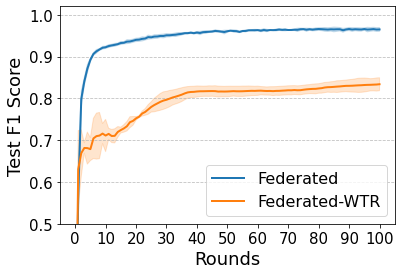

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define algorithms and their corresponding legend labels
algorithms = ["MLP_fed_avg_TR", "MLP_fed_avg_WTR", ]

# Select the metric to visualize
metric = "server_F1_Score"  # Change this to other metrics if needed
legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR", "MLP_fed_avg_TR": "Federated"}  # Custom legend labels

# metric = "train_f1_score"  # Change this to other metrics if needed
# legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR (Clients 1-8)", "MLP_fed_avg_TR": "Federated (Clients 1-8)"}  # Custom legend labels


# Use Seaborn color palette
sns.set_palette("tab10")  # Options: "deep", "muted", "bright", "dark", etc.
colors = sns.color_palette("tab10", n_colors=len(algorithms))  # Get distinct colors

# Assign colors dynamically
color_map = {algorithms[i]: colors[i] for i in range(len(algorithms))}

# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create the plot
plt.figure(figsize=(6, 4))

for algo in algorithms:
    df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
    # df_algo = df_mean_std[(df_mean_std["Algorithm"] == algo) & (df_mean_std["Step"] != 0)]
    
    steps = df_algo["Step"]
    mean_values = df_algo[f"{metric}_mean"]  # Scale Y-axis to percentage
    std_values = df_algo[f"{metric}_std"]   # Scale std to percentage

    # Plot mean line with custom label
    plt.plot(steps, mean_values, label=legend_labels[algo], color=color_map[algo], linewidth=2)

    # Add shaded region for standard deviation
    plt.fill_between(steps, mean_values - std_values, mean_values + std_values, color=color_map[algo], alpha=0.2)

# Labels and styling
plt.xlabel("Rounds", fontsize=axis_label_fontsize)
if "server" in metric:
    plt.ylabel("Test F1 Score", fontsize=axis_label_fontsize)
else:
    plt.ylabel("Train F1 Score", fontsize=axis_label_fontsize)
plt.xticks(range(0, steps.max() + 1, 10), fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.ylim(0.5, 1.02)  # Set Y-axis limits to


# Add legend with custom font size
# plt.legend(fontsize=legend_fontsize, loc="upper center", bbox_to_anchor=(0.5, 1.17), ncol=2, )
plt.legend(fontsize=legend_fontsize, loc="best", ncol=1, )

# Restore only horizontal grid lines
plt.grid(True, axis='y', linestyle='--', alpha=0.8)

# save plot in pdf
plt.savefig(f'{metric}.pdf', bbox_inches='tight')

# Show the plot
plt.show()



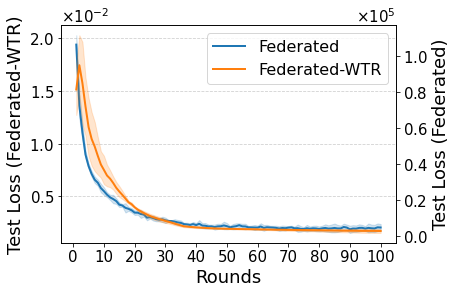

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker  # Import ticker for scientific notation

# Select the metric to visualize
metric = "server_loss"  # Change this to other loss metrics if needed
legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR", "MLP_fed_avg_TR": "Federated"}  # Custom legend labels

# metric = "train_loss"  # Change this to other loss metrics if needed
# legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR (Clients 1-8)", "MLP_fed_avg_TR": "Federated (Clients 1-8)"}  # Custom legend labels


# Define algorithms and their corresponding legend labels
algorithms = ["MLP_fed_avg_TR", "MLP_fed_avg_WTR"]

# Use Seaborn color palette
sns.set_palette("tab10")  # Options: "deep", "muted", "bright", "dark", etc.
colors = sns.color_palette("tab10", n_colors=len(algorithms))  # Get distinct colors

# Assign colors dynamically
color_map = {algorithms[i]: colors[i] for i in range(len(algorithms))}

# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 4))

# Create a second Y-axis
ax2 = ax1.twinx()

# Store legend handles
handles = []
labels = []

# Plot each algorithm's loss metric on the appropriate axis
for i, algo in enumerate(algorithms):
    df_algo = df_mean_std[(df_mean_std["Algorithm"] == algo) & (df_mean_std["Step"] != 0)]
    
    steps = df_algo["Step"]
    mean_values = df_algo[f"{metric}_mean"]
    std_values = df_algo[f"{metric}_std"]

    ax = ax1 if i == 0 else ax2  # Assign the correct axis
    line, = ax.plot(steps, mean_values, label=legend_labels[algo], color=color_map[algo], linewidth=2)
    ax.fill_between(steps, mean_values - std_values, mean_values + std_values, color=color_map[algo], alpha=0.2)

    # Store handles and labels for merged legend
    handles.append(line)
    labels.append(legend_labels[algo])

# Labels and styling
plt.xticks(range(0, steps.max() + 1, 10), fontsize=tick_fontsize)

# Configure axis labels
ax1.set_xlabel("Rounds", fontsize=axis_label_fontsize)
    
if "server" in metric:
    ax1.set_ylabel("Test Loss (Federated-WTR)", fontsize=axis_label_fontsize)
    ax2.set_ylabel("Test Loss (Federated)", fontsize=axis_label_fontsize)
else:
    ax1.set_ylabel("Train Loss (Federated-WTR)", fontsize=axis_label_fontsize)
    ax2.set_ylabel("Train Loss (Federated)", fontsize=axis_label_fontsize)

# Adjust tick font sizes
ax1.tick_params(axis='both', labelsize=tick_fontsize)
ax2.tick_params(axis='both', labelsize=tick_fontsize)


# Format Y-axis in scientific notation and move exponent to the top
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-1, 1))  # Controls when scientific notation is applied
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax1.yaxis.offsetText.set_fontsize(tick_fontsize)  # Increase exponent font size
ax2.yaxis.offsetText.set_fontsize(tick_fontsize)  # Increase exponent font size


# Add a single merged legend
# ax1.legend(handles, labels, fontsize=legend_fontsize, loc="upper center", bbox_to_anchor=(0.5, 1.27), ncol=2, frameon=True)
ax1.legend(handles, labels, fontsize=legend_fontsize, loc="best")

# Restore only horizontal grid lines
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Save the plot as a PDF file
plt.savefig(f'{metric}.pdf', bbox_inches='tight')
# Show the plot
plt.show()


In [19]:

# List of metrics to analyze (excluding 'Step' and 'Algorithm')
metrics = [col for col in df_mean_std.columns if col not in ["Algorithm", "Step"] and not "std" in col and not "loss" in col]

# Initialize a dictionary to store results
max_results = []

# Loop through each algorithm and each metric
for algo in df_mean_std["Algorithm"].unique():
    df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
    
    for metric in metrics:
        max_row = df_algo.loc[df_algo[metric].idxmax()]  # Get the row where max happens
        max_results.append({
            "Algorithm": algo,
            "Metric": metric,
            "Max Value": max_row[metric],
            "Step": max_row["Step"]
        })

# Convert results into a DataFrame
df_max_metrics = pd.DataFrame(max_results)

df_max_metrics

,Algorithm,Metric,Max Value,Step
0,MLP_fed_avg_TR,server_accuracy_mean,0.965629,90
1,MLP_fed_avg_TR,server_precision_mean,0.967652,80
2,MLP_fed_avg_TR,server_recall_mean,0.965629,90
3,MLP_fed_avg_TR,server_F1_Score_mean,0.965816,90
4,MLP_fed_avg_TR,train_accuracy_mean,0.996493,98
5,MLP_fed_avg_TR,train_f1_score_mean,0.996494,98
6,MLP_fed_avg_WTR,server_accuracy_mean,0.829949,100
7,MLP_fed_avg_WTR,server_precision_mean,0.858485,100
8,MLP_fed_avg_WTR,server_recall_mean,0.829949,100
9,MLP_fed_avg_WTR,server_F1_Score_mean,0.833782,100


In [31]:
# algorithm = "MLP_fed_avg_TR"
algorithm = "MLP_fed_avg_WTR"
step = 100
row = df_mean_std[(df_mean_std["Algorithm"] == algorithm) & (df_mean_std["Step"] == step)]
metrics = ["server_accuracy_mean", "server_precision_mean", "server_recall_mean", "server_F1_Score_mean", "train_accuracy_mean", "train_f1_score_mean"]

metrics_values = {metric: round(row[metric].values[0] * 100, 2) for metric in metrics}
metrics_values

{'server_accuracy_mean': 82.99,
 'server_precision_mean': 85.85,
 'server_recall_mean': 82.99,
 'server_F1_Score_mean': 83.38,
 'train_accuracy_mean': 95.6,
 'train_f1_score_mean': 95.56}